In [1]:
%matplotlib notebook

import os
from glob import glob
from tqdm import tqdm

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import numpy as np
import pandas as pd

import mdtraj as md

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

## Some conclusions from this notebook:

* Changes in unit cell parameters appear to describe most of the variation in the data, but not all.
* The 3rd PC doesn't correlate well with any cell parameter. The data cluster in two groups along this linear direction. Currently, what causes this variation in the data is unknown.

In [3]:
def compute_volume(df):
    # only for monoclinic...
    df['volume'] = df['a'] * df['b'] * df['c'] * np.sin(np.radians(df['beta'])) / 1000. # nm^3
    return


def traj_to_cell_dataframe(traj):
    data = np.hstack([ traj.unitcell_lengths * 10, traj.unitcell_angles ])
    df = pd.DataFrame(data, columns=['a', 'b', 'c', 'alpha', 'beta', 'gamma'])
    compute_volume(df)
    return df


def dir_to_trj(path, load_cells=False):
    
    pdb_list = glob(path + '/*.pdb')
    print('found %d hit pdbs' % len(pdb_list))

    structures = None
    cells = []
    
    for pdb in tqdm(pdb_list):

        try:

            trj = md.load_pdb(pdb)
            idx = trj.top.select('(type != H) and is_protein')
            trj = trj.atom_slice(idx)

            if structures:
                structures = structures.join(trj)
            else:
                structures = trj
                
            if load_cells:
                cell = np.concatenate( [trj.unitcell_lengths[0]*10.0,
                                        trj.unitcell_angles[0], 
                                        trj.unitcell_volumes] )
                cells.append(cell)

        except Exception as e:
            print(pdb, e)
            print(trj.n_atoms, structures.n_atoms)

    structures = structures.center_coordinates()
    print('final num loaded:', len(structures))

    if load_cells:
        cells = np.array(cells)
        return structures, cells
    else:
        return structures
    
    
def featurize_all_dihedrals(traj):
    
    features = []
    for fxn in [md.compute_phi,
                md.compute_psi]:
        _, angles = fxn(traj)
        
        features.append( np.sin(angles) )
        features.append( np.cos(angles) )
    
    return np.hstack(features)

In [5]:
SELECTED_DATASET_PDBS = '../../allostery/selected_dataset_archive_2023-01-14/pdb'
apo_wcell, cells = dir_to_trj(SELECTED_DATASET_PDBS, load_cells=True)

found 1146 hit pdbs


100%|██████████| 1146/1146 [04:45<00:00,  4.01it/s]

final num loaded: 1146


## PCA on Torsion Angles

In [21]:
pca = PCA(n_components=8, svd_solver='full', whiten=True)

X_tr = featurize_all_dihedrals(apo_wcell)
Y_tr = pca.fit_transform(X_tr)

<IPython.core.display.Javascript object>


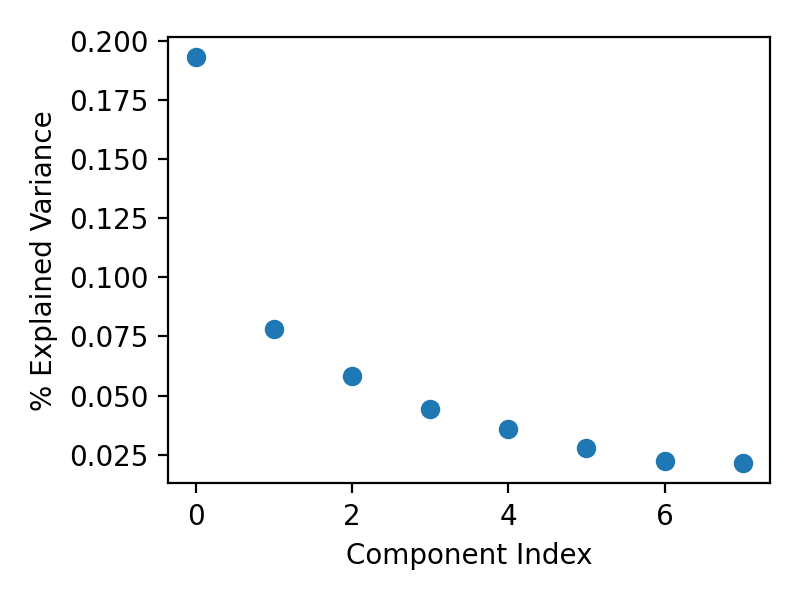

0.27127543


In [22]:
plt.figure(figsize=(4,3))
plt.plot(pca.explained_variance_ratio_, 'o')
plt.xlabel('Component Index')
plt.ylabel('% Explained Variance')

plt.tight_layout()
plt.savefig('figures/Hb_pca_explained_variance.pdf')
plt.show()

print(pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1])

<IPython.core.display.Javascript object>


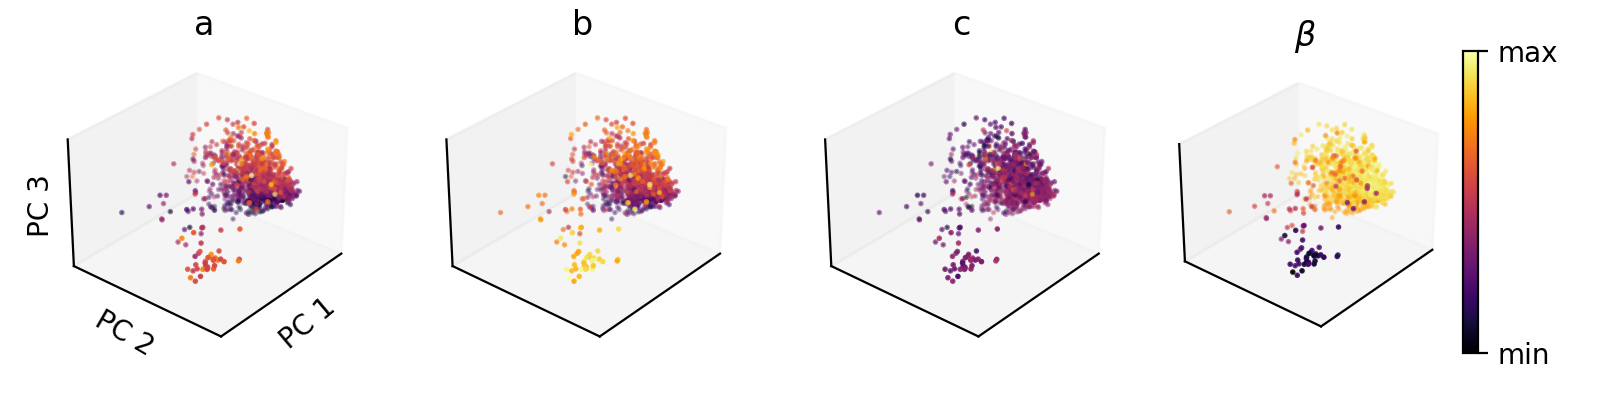

In [102]:
# the top 3 PCs

cell_labels = ['a', 'b', 'c', r'$\beta$', 'V']

fig = plt.figure(figsize=(8, 2))

for ax_i in range(4):

    ax = fig.add_subplot(1, 4, ax_i+1, projection='3d', elev=30, azim=40)
    ax.set_title(cell_labels[ax_i])

    if ax_i == 3:
        c_i = 4 # skip alpha
    elif ax_i == 4:
        c_i = 6 # skip alpha, gamma
    else:
        c_i = ax_i
    
    s = ax.scatter( Y_tr[:,0], 
                   -Y_tr[:,1], 
                    Y_tr[:,2], 
                   cmap='inferno',
                   s=1,
                   c=cells[:,c_i])

    if ax_i == 0:
        ax.set_xlabel('PC 1', labelpad=-12, rotation=40)
        ax.set_ylabel('PC 2', labelpad=-12, rotation=-30)
        ax.set_zlabel('PC 3', labelpad=-15, rotation=90)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

cbar = fig.colorbar(s, ticks=[cells[:,c_i].min(), cells[:,c_i].max()])
cbar.ax.set_yticklabels(['min', 'max']) 
    
plt.tight_layout()
plt.savefig('./figures/cell_params_v_structure_PCA_torsion.pdf')
plt.show()

<IPython.core.display.Javascript object>


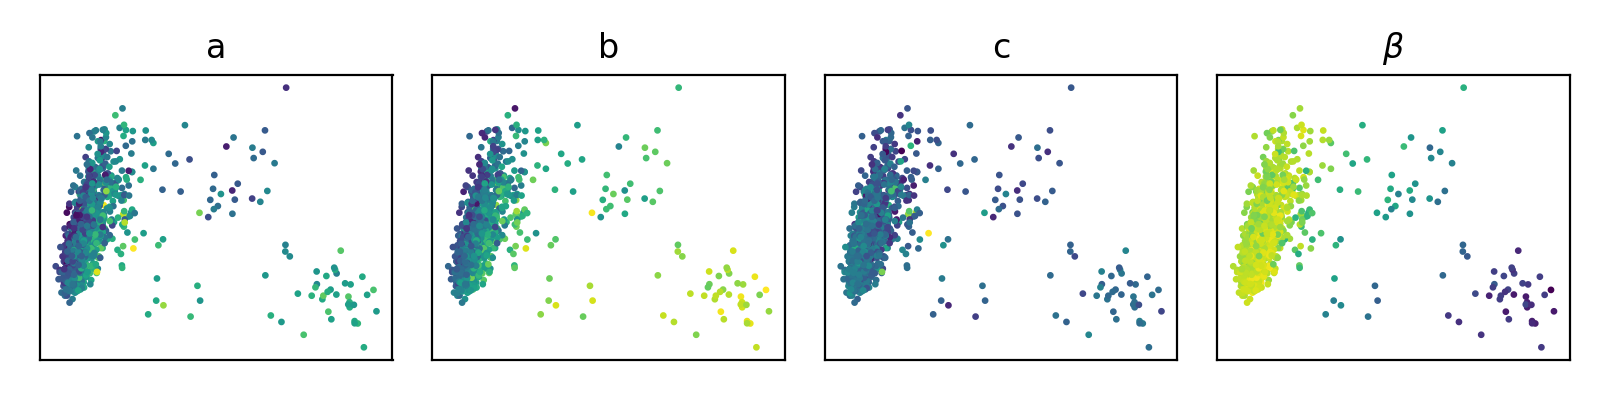

In [27]:
fig = plt.figure(figsize=(8,2))

for ax_i in range(4):

    ax = fig.add_subplot(1, 4, ax_i+1)
    ax.set_title(cell_labels[ax_i])
    ax.set_xticks([])
    ax.set_yticks([])

    if ax_i == 3:
        c_i = 4 # skip alpha
    elif ax_i == 4:
        c_i = 6 # skip alpha, gamma
    else:
        c_i = ax_i

    plt.scatter(Y_tr[:,0], Y_tr[:,1], s=2, c=cells[:,c_i])
    
plt.tight_layout()
plt.show()

## tSNE on Torsions

In [ ]:
Y_sne = TSNE(n_components=2, init='random', perplexity=5.0).fit_transform(X_tr)

<IPython.core.display.Javascript object>


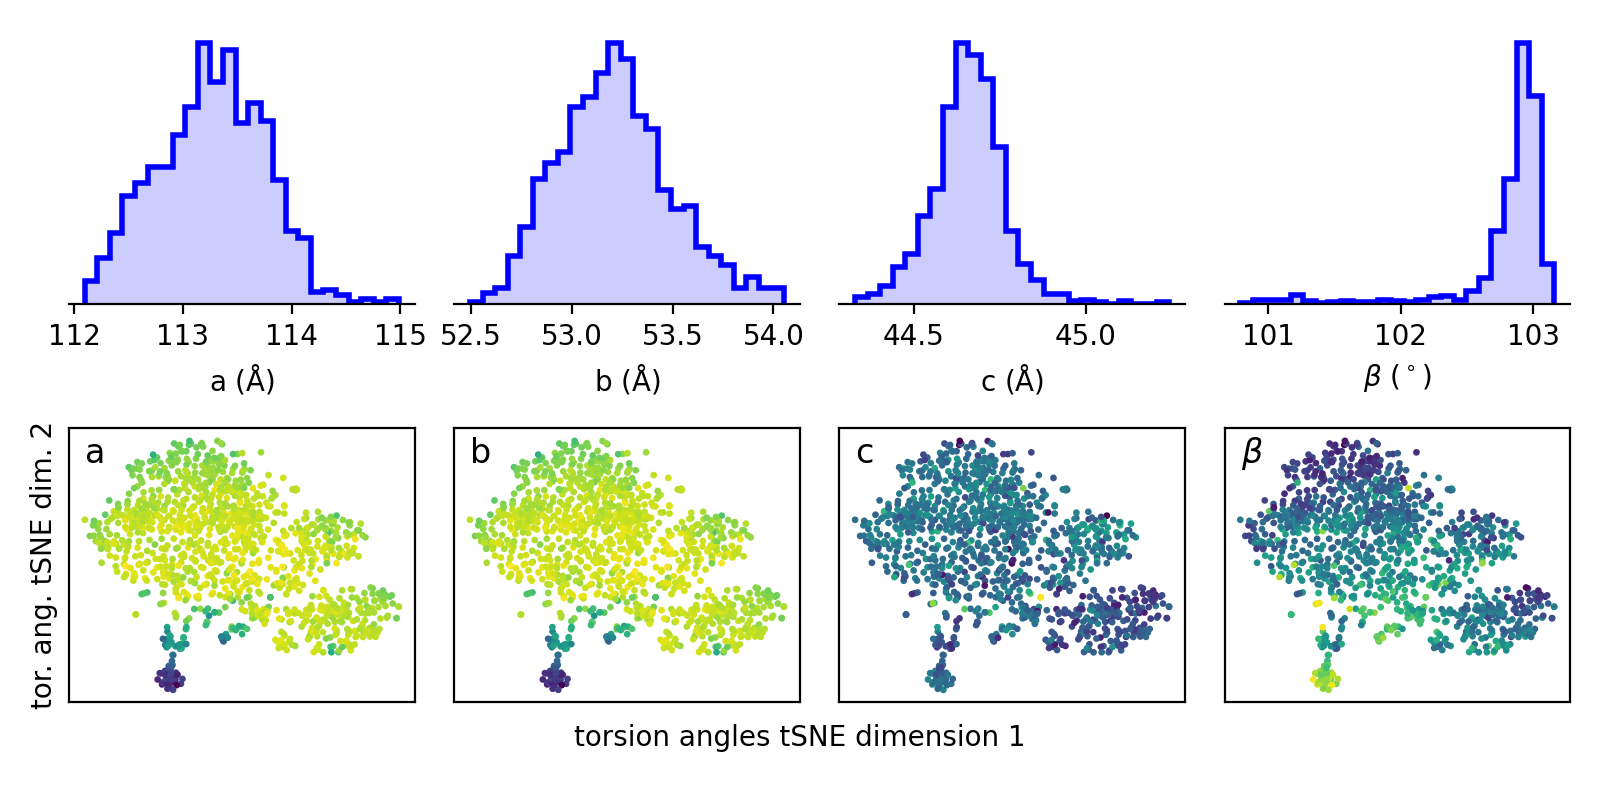

In [117]:
bins = 25

fig = plt.figure(figsize=(8,4))


for ax_i in range(4):

    ax = fig.add_subplot(2, 4, ax_i+1)
    
    #ax.set_xticks([])
    ax.set_yticks([])
    
    
    ax.spines[['right', 'top', 'left']].set_visible(False)
    #ax.text(-44, 28, cell_labels[ax_i], fontsize=12)

    if ax_i == 3:
        c_i = 4 # skip alpha
        unit = r" ($^\circ$)"
    elif ax_i == 4:
        c_i = 6 # skip alpha, gamma
    else:
        c_i = ax_i
        unit = r" ($\mathrm{\AA}$)"
        
    ax.set_xlabel(cell_labels[ax_i] + unit)

    ax.hist(cells[:,c_i], histtype="step", color="blue", lw=2, bins=bins)
    s = ax.hist(cells[:,c_i], alpha=0.2, color="blue", bins=bins)


for ax_i in range(4, 8):

    ax = fig.add_subplot(2, 4, ax_i+1)
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    #ax.set_title(cell_labels[ax_i])

    if ax_i == 4:
        ax.set_ylabel("tor. ang. tSNE dim. 2", fontsize=10)
    elif ax_i == 5:
        c_i = 4 # skip alpha
    elif ax_i == 7:
        c_i = 6 # skip alpha, gamma
    else:
        c_i = ax_i - 4

    ax.text(-0.9, 0.80, cell_labels[ax_i-4], fontsize=12)
    s = ax.scatter(
        Y_sne[:,0] / Y_sne[:,0].max(), 
        Y_sne[:,1] / Y_sne[:,1].max(), 
        s=2, 
        c=cells[:,c_i]
    )

    
# cbar = fig.colorbar(s, ticks=[cells[:,c_i].min(), cells[:,c_i].max()])
# cbar.ax.set_yticklabels(['min', 'max'])
# cbar.ax.set_ylabel('cell param. val.', rotation=270, labelpad=-4)

fig.supxlabel("torsion angles tSNE dimension 1", x=0.5, y=0.06, fontsize=10)

plt.tight_layout()
plt.savefig('./figures/torsion_tSNE.pdf')
plt.show()

<IPython.core.display.Javascript object>


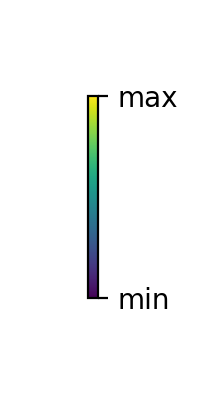

In [93]:
plt.figure(figsize=(1, 2))

img = plt.imshow(np.array([[0,1]]))
plt.gca().set_visible(False)

cbar = plt.colorbar(orientation="vertical", ticks=[0,1])
cbar.ax.set_yticklabels(['min', 'max'])

plt.tight_layout()
plt.savefig("./figures/colorbar.pdf")

plt.show()